# 🐍 Snake Classifier - EfficientNet-B0 + ML Pipeline

| Component | Description |
|-----------|-------------|
| **Features** | EfficientNet-B0 (ImageNet) -> 1280-dim |
| **Models** | LinearSVC, Logistic Regression |
| **Tuning** | GridSearchCV with StratifiedKFold |
| **Runtime** | PyTorch (Feature Extraction) + Scikit-Learn (Classification) |

## 0. Dependency Check
Ensure PyTorch and other key libraries are installed.

In [9]:
try:
    import torch
    import torchvision
    import sklearn
    import joblib
    import cv2

    print(f"[OK] Torch: {torch.__version__} | CUDA: {torch.cuda.is_available()}")
    print(f"[OK] Torchvision: {torchvision.__version__}")
    print(f"[OK] Scikit-Learn: {sklearn.__version__}")
    print(f"[OK] OpenCV: {cv2.__version__}")
except ImportError as e:
    print(f"[ERROR] Missing dependency: {e}")
    print("\nInstalling missing core dependencies (Torch with CUDA 11.8 support)...")
    # !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

[OK] Torch: 2.10.0+cpu | CUDA: False
[OK] Torchvision: 0.25.0+cpu
[OK] Scikit-Learn: 1.6.1
[OK] OpenCV: 4.13.0


## 1. Setup

In [10]:
import os, sys, time, warnings, random
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import cv2
from IPython.display import display

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, top_k_accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, precision_recall_fscore_support
)

# Mount Google Drive if in Colab
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    PROJECT_ROOT = '/content/drive/MyDrive/Miniproject Snake'
except:
    PROJECT_ROOT = os.path.abspath('')

# Set PROJECT_ROOT and path
if os.path.exists(PROJECT_ROOT):
    os.chdir(PROJECT_ROOT)
    if PROJECT_ROOT not in sys.path:
        sys.path.insert(0, PROJECT_ROOT)
    print(f'Project root set to: {PROJECT_ROOT}')

plt.rcParams.update({'figure.dpi': 120})
PALETTE = sns.color_palette('deep')
print('Imports OK')

Mounted at /content/drive
Project root set to: /content/drive/MyDrive/Miniproject Snake
Imports OK


In [11]:
from src.utils.config import (
    DATASET_PATH, PROCESSED_DATA_PATH, ARTIFACTS_PATH,
    RANDOM_SEED, TEST_SPLIT, FEATURE_DIM, BATCH_SIZE,
    MODEL_TYPES, PARAM_GRIDS, CV_FOLDS, TUNING_FOLDS
)
from src.utils.safety import is_venomous

print(f'Dataset: {DATASET_PATH}')
print(f'Features: EfficientNet-B0 ({FEATURE_DIM}-dim)')
print(f'Models: {MODEL_TYPES}')

Dataset: /content/drive/MyDrive/Miniproject Snake/venomous_data
Features: EfficientNet-B0 (1280-dim)
Models: ['linearsvc', 'logreg']


## 2. Feature Extraction

In [12]:
from src.features.pipeline import process_dataset, load_features

X, y, label_names, image_paths = load_features()

if X is None:
    print('Extracting features...')
    X, y, label_names, image_paths = process_dataset(use_batch=True, batch_size=BATCH_SIZE)
else:
    print('Features loaded from cache')

label_names = np.array(label_names)
print(f'Shape: {X.shape} | Classes: {len(np.unique(y))}')

Extracting features...

Feature Extraction: EfficientNet-B0 (1280-dim)
Found 10 species
Total images: 1000
Extracting in batches (batch_size=32)...
Loading EfficientNet-B0 (ImageNet pretrained)...
Using device: cpu
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 115MB/s] 


EfficientNet-B0 loaded successfully. Output: 1280-dim

Extraction complete: (1000, 1280)
Saved -> /content/drive/MyDrive/Miniproject Snake/data/processed/features.npz
Shape: (1000, 1280) | Classes: 10


## 3. Train/Test Split

In [13]:
# Split indices to track image paths
indices = np.arange(len(X))
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, indices, test_size=TEST_SPLIT, stratify=y, random_state=RANDOM_SEED
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')

# Scale
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print('Data scaled')

Train: (800, 1280) | Test: (200, 1280)
Data scaled


## 4. Hyperparameter Tuning

In [14]:
def get_base_model(model_type):
    if model_type == 'linearsvc':
        return LinearSVC(class_weight='balanced', dual=True, random_state=RANDOM_SEED, max_iter=10000)
    elif model_type == 'logreg':
        return LogisticRegression(class_weight='balanced', random_state=RANDOM_SEED)

best_params = {}
skf = StratifiedKFold(n_splits=TUNING_FOLDS, shuffle=True, random_state=RANDOM_SEED)

for model_type in MODEL_TYPES:
    if model_type not in PARAM_GRIDS: continue
    print(f'\nTuning {model_type.upper()}...')
    grid = GridSearchCV(
        get_base_model(model_type),
        PARAM_GRIDS[model_type],
        cv=skf, scoring='accuracy', n_jobs=-1
    )
    grid.fit(X_train_s, y_train)
    best_params[model_type] = grid.best_params_
    print(f'  Best: {grid.best_params_}')
    print(f'  CV Score: {grid.best_score_*100:.2f}%')


Tuning LINEARSVC...
  Best: {'C': 0.1, 'loss': 'squared_hinge'}
  CV Score: 61.75%

Tuning LOGREG...
  Best: {'C': 0.1, 'max_iter': 2000, 'penalty': 'l2', 'solver': 'saga'}
  CV Score: 66.50%


## 5. Train Models

In [15]:
models = {}
train_times = {}

for model_type in MODEL_TYPES:
    print(f'\nTraining {model_type.upper()}...')
    params = best_params.get(model_type, {})

    if model_type == 'linearsvc':
        m = LinearSVC(C=params.get('C', 1), loss=params.get('loss', 'squared_hinge'),
                     class_weight='balanced', dual=True, random_state=RANDOM_SEED, max_iter=10000)
    elif model_type == 'logreg':
        m = LogisticRegression(C=params.get('C', 1), solver=params.get('solver', 'lbfgs'),
                              class_weight='balanced', random_state=RANDOM_SEED, max_iter=2000)
    else: continue

    t0 = time.time()
    m.fit(X_train_s, y_train)
    train_times[model_type] = time.time() - t0
    models[model_type] = m
    print(f'  Done in {train_times[model_type]:.2f}s')


Training LINEARSVC...
  Done in 13.90s

Training LOGREG...
  Done in 27.78s


## 6. Evaluation

In [16]:
eval_results = {}

for name, m in models.items():
    y_pred = m.predict(X_test_s)
    if hasattr(m, 'decision_function'):
        scores = m.decision_function(X_test_s)
    else:
        scores = m.predict_proba(X_test_s)

    top1 = accuracy_score(y_test, y_pred)
    top3 = top_k_accuracy_score(y_test, scores, k=3)
    top5 = top_k_accuracy_score(y_test, scores, k=5)

    eval_results[name] = {
        'top1': top1, 'top3': top3, 'top5': top5,
        'y_pred': y_pred, 'scores': scores
    }
    print(f'{name.upper()}: Top-1={top1*100:.2f}% | Top-3={top3*100:.2f}% | Top-5={top5*100:.2f}%')

LINEARSVC: Top-1=62.00% | Top-3=83.00% | Top-5=91.00%
LOGREG: Top-1=66.50% | Top-3=90.50% | Top-5=97.50%


## 7. Model Comparison

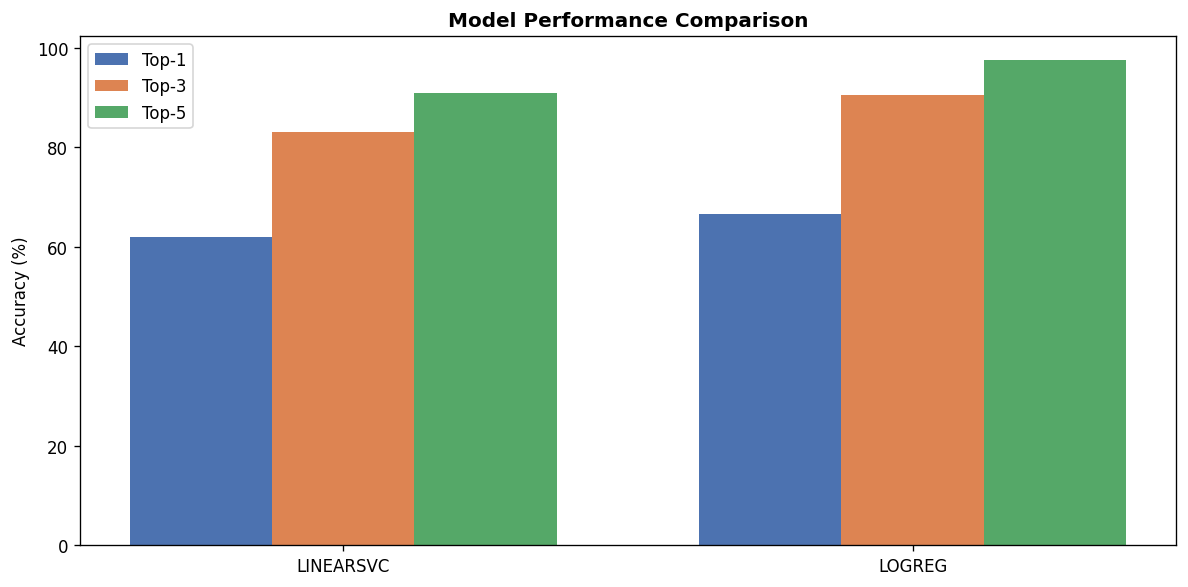

In [17]:
# Accuracy chart
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(models))
width = 0.25

t1 = [eval_results[m]['top1']*100 for m in models]
t3 = [eval_results[m]['top3']*100 for m in models]
t5 = [eval_results[m]['top5']*100 for m in models]

ax.bar(x - width, t1, width, label='Top-1', color=PALETTE[0])
ax.bar(x, t3, width, label='Top-3', color=PALETTE[1])
ax.bar(x + width, t5, width, label='Top-5', color=PALETTE[2])

ax.set_xticks(x)
ax.set_xticklabels([m.upper() for m in models])
ax.set_ylabel('Accuracy (%)')
ax.set_title('Model Performance Comparison', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [18]:
# Final Summary Table
rows = []
for name in models:
    rows.append({
        'Model': name.upper(),
        'Top-1 (%)': round(eval_results[name]['top1']*100, 2),
        'Top-3 (%)': round(eval_results[name]['top3']*100, 2),
        'Top-5 (%)': round(eval_results[name]['top5']*100, 2),
        'Train Time (s)': round(train_times[name], 4)
    })

df_summary = pd.DataFrame(rows).set_index('Model')
display(df_summary.style.highlight_max(subset=['Top-1 (%)'], color='#c6efce'))

BEST = max(eval_results, key=lambda x: eval_results[x]['top1'])
print(f'\nSelected Best Model: {BEST.upper()}')

,Top-1 (%),Top-3 (%),Top-5 (%),Train Time (s)
Model,,,,
LINEARSVC,62.000000,83.000000,91.000000,13.901300
LOGREG,66.500000,90.500000,97.500000,27.782200



Selected Best Model: LOGREG


## 8. Save Artifacts

In [19]:
for name, m in models.items():
    out_dir = os.path.join(ARTIFACTS_PATH, name)
    os.makedirs(out_dir, exist_ok=True)

    joblib.dump(scaler, os.path.join(out_dir, 'scaler.pkl'))
    joblib.dump(m, os.path.join(out_dir, 'model.pkl'))
    joblib.dump(label_names, os.path.join(out_dir, 'label_names.pkl'))
    if name in best_params:
        joblib.dump(best_params[name], os.path.join(out_dir, 'best_params.pkl'))

    print(f'Saved artifacts for: {name}')

Saved artifacts for: linearsvc
Saved artifacts for: logreg


## 9. Deep Evaluation (Best Model)

In [20]:
y_pred = eval_results[BEST]['y_pred']
target_names = label_names[np.unique(y_test).astype(int)]

print(f'Classification Report: {BEST.upper()}')
print('-' * 60)
print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))

Classification Report: LOGREG
------------------------------------------------------------
                                  precision    recall  f1-score   support

              Bungarus_caeruleus       0.81      0.85      0.83        20
    Craspedocephalus_malabaricus       0.70      0.80      0.74        20
Craspedocephalus_trigonocephalus       0.78      0.90      0.84        20
                 Fowlea_piscator       0.50      0.55      0.52        20
                 Hypnale_hypnale       0.79      0.75      0.77        20
                    Hypnale_zara       0.83      0.75      0.79        20
               Lycodon_capucinus       0.54      0.65      0.59        20
                       Naja_naja       0.53      0.50      0.51        20
              Ophiophagus_hannah       0.60      0.60      0.60        20
                    Ptyas_mucosa       0.55      0.30      0.39        20

                        accuracy                           0.67       200
                   

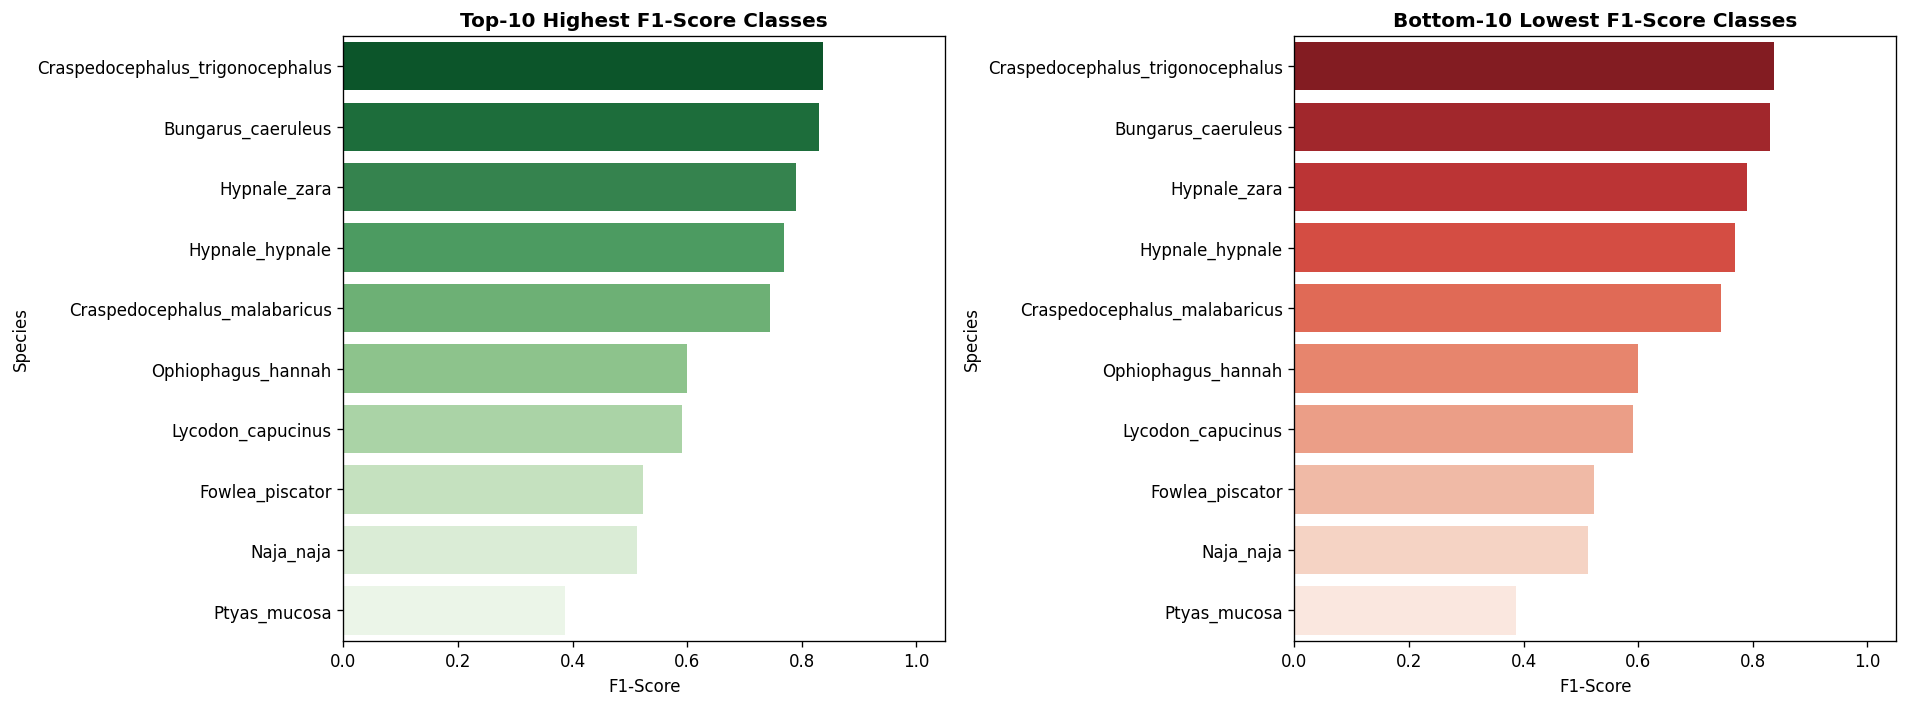

In [21]:
# Detailed Per-Class Performance (F1-Score)
precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred, zero_division=0)
f1_df = pd.DataFrame({
    'Species': target_names,
    'F1-Score': f1,
    'Precision': precision,
    'Recall': recall,
    'Samples': support
}).sort_values('F1-Score', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=f1_df.head(10), x='F1-Score', y='Species', ax=axes[0], palette='Greens_r')
axes[0].set_title('Top-10 Highest F1-Score Classes', fontweight='bold')
axes[0].set_xlim(0, 1.05)

sns.barplot(data=f1_df.tail(10), x='F1-Score', y='Species', ax=axes[1], palette='Reds_r')
axes[1].set_title('Bottom-10 Lowest F1-Score Classes', fontweight='bold')
axes[1].set_xlim(0, 1.05)

plt.tight_layout()
plt.show()

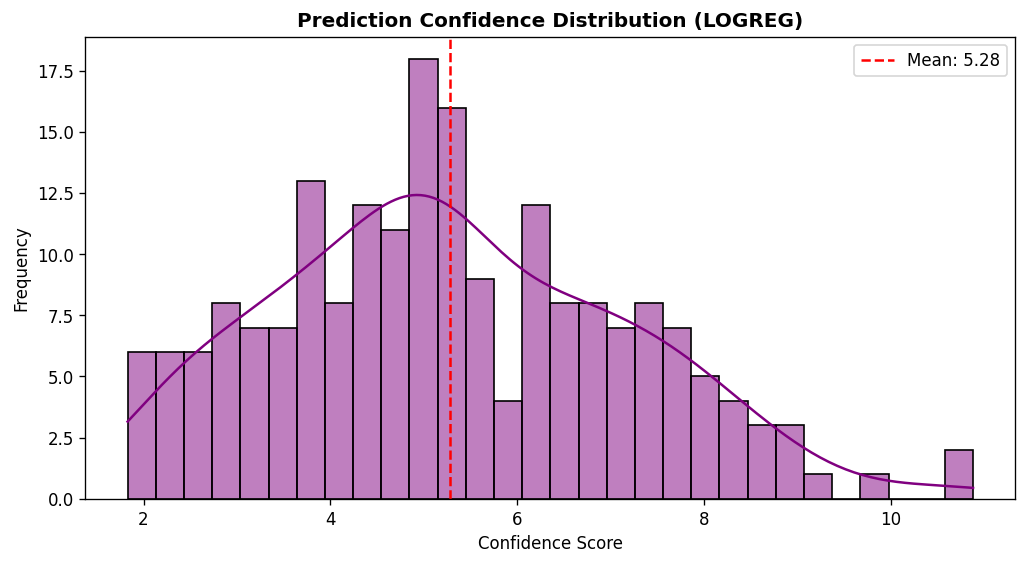

In [22]:
# Prediction Confidence Distribution
scores = eval_results[BEST]['scores']
if BEST == 'logreg':
    confidences = np.max(scores, axis=1)
else:
    # For LinearSVC, normalize the decision scores
    confidences = np.max(scores, axis=1)
    confidences = (confidences - confidences.min()) / (confidences.max() - confidences.min())

plt.figure(figsize=(10, 5))
sns.histplot(confidences, bins=30, kde=True, color='purple')
plt.title(f'Prediction Confidence Distribution ({BEST.upper()})', fontweight='bold')
plt.xlabel('Confidence Score')
plt.ylabel('Frequency')
plt.axvline(confidences.mean(), color='red', linestyle='--', label=f'Mean: {confidences.mean():.2f}')
plt.legend()
plt.show()

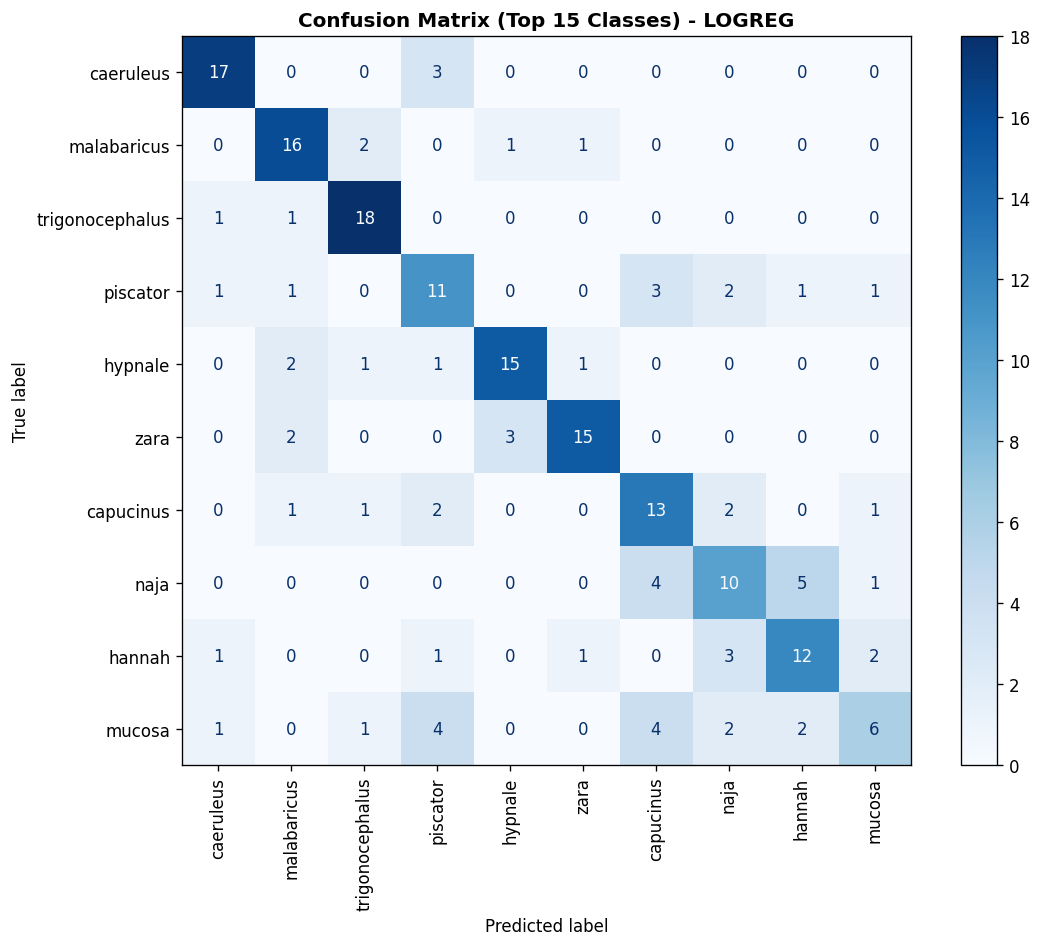

In [23]:
# Confusion Matrix for Top 15 Most Common Test Classes
counts = np.bincount(y_test.astype(int))
top_cls_indices = np.argsort(counts)[-15:]
mask = np.isin(y_test, top_cls_indices)

cm = confusion_matrix(y_test[mask], y_pred[mask], labels=top_cls_indices)
cm_labels = [label_names[i].split('_')[-1] for i in top_cls_indices]

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(cm, display_labels=cm_labels).plot(ax=ax, cmap='Blues', xticks_rotation=90)
ax.set_title(f'Confusion Matrix (Top 15 Classes) - {BEST.upper()}', fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Safety Analysis: Venomous vs Non-venomous

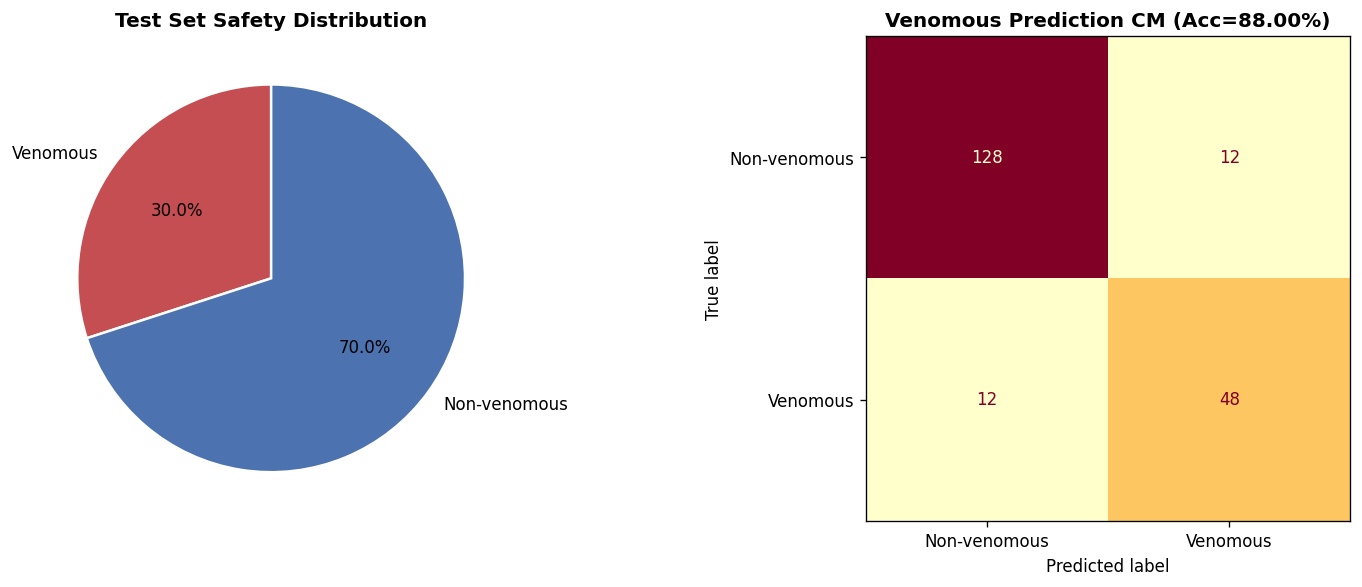

              precision    recall  f1-score   support

Non-venomous       0.91      0.91      0.91       140
    Venomous       0.80      0.80      0.80        60

    accuracy                           0.88       200
   macro avg       0.86      0.86      0.86       200
weighted avg       0.88      0.88      0.88       200



In [24]:
venom_true = np.array([is_venomous(label_names[int(i)])[0] for i in y_test])
venom_pred = np.array([is_venomous(label_names[int(i)])[0] for i in y_pred])
venom_acc  = accuracy_score(venom_true, venom_pred)
cm_v       = confusion_matrix(venom_true, venom_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].pie([venom_true.sum(), (len(venom_true) - venom_true.sum())],
            labels=['Venomous', 'Non-venomous'],
            colors=[PALETTE[3], PALETTE[0]],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[0].set_title('Test Set Safety Distribution', fontweight='bold')

ConfusionMatrixDisplay(cm_v, display_labels=['Non-venomous', 'Venomous']).plot(
    ax=axes[1], colorbar=False, cmap='YlOrRd'
)
axes[1].set_title(f'Venomous Prediction CM (Acc={venom_acc*100:.2f}%)', fontweight='bold')
plt.tight_layout(); plt.show()

print(classification_report(venom_true, venom_pred,
      target_names=['Non-venomous', 'Venomous'], zero_division=0))

## 11. Per-Species Accuracy Distribution

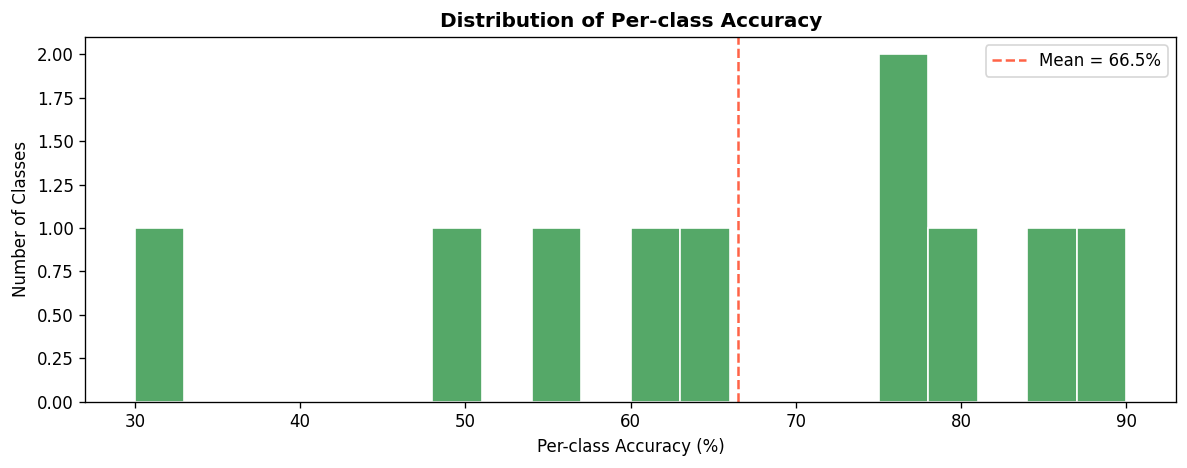

Mean Species Accuracy: 66.50%


,Accuracy (%)
Craspedocephalus_trigonocephalus,90.0
Bungarus_caeruleus,85.0
Craspedocephalus_malabaricus,80.0
Hypnale_hypnale,75.0
Hypnale_zara,75.0
Lycodon_capucinus,65.0
Ophiophagus_hannah,60.0
Fowlea_piscator,55.0
Naja_naja,50.0
Ptyas_mucosa,30.0


In [25]:
correct = (y_test == y_pred)
class_accs = {label_names[int(cls_id)]: correct[y_test == cls_id].mean() * 100
              for cls_id in np.unique(y_test)}

acc_df = pd.DataFrame.from_dict(class_accs, orient='index', columns=['Accuracy (%)'])\
                     .sort_values('Accuracy (%)', ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(acc_df['Accuracy (%)'], bins=20, color=PALETTE[2], edgecolor='white')
ax.axvline(acc_df['Accuracy (%)'].mean(), color='tomato', linestyle='--',
           label=f"Mean = {acc_df['Accuracy (%)'].mean():.1f}%")
ax.set_xlabel('Per-class Accuracy (%)'); ax.set_ylabel('Number of Classes')
ax.set_title('Distribution of Per-class Accuracy', fontweight='bold'); ax.legend()
plt.tight_layout(); plt.show()

print(f'Mean Species Accuracy: {acc_df["Accuracy (%)"].mean():.2f}%')
acc_df.head(10)

## 12. Sample Visual Predictions

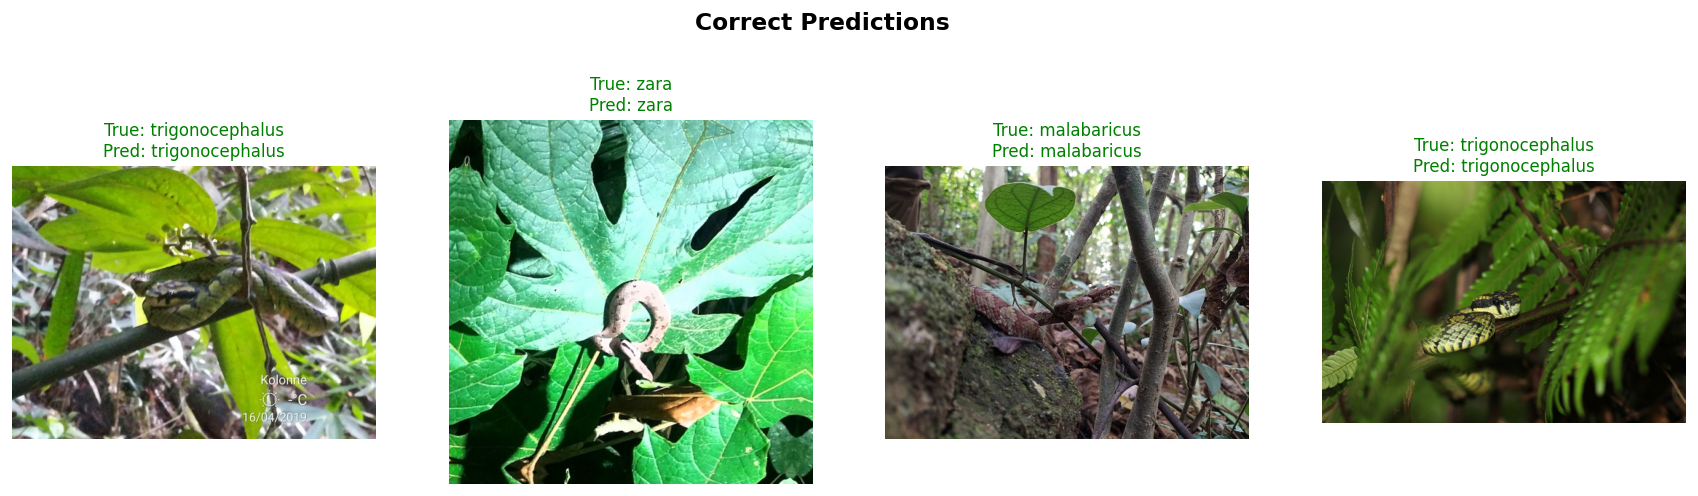

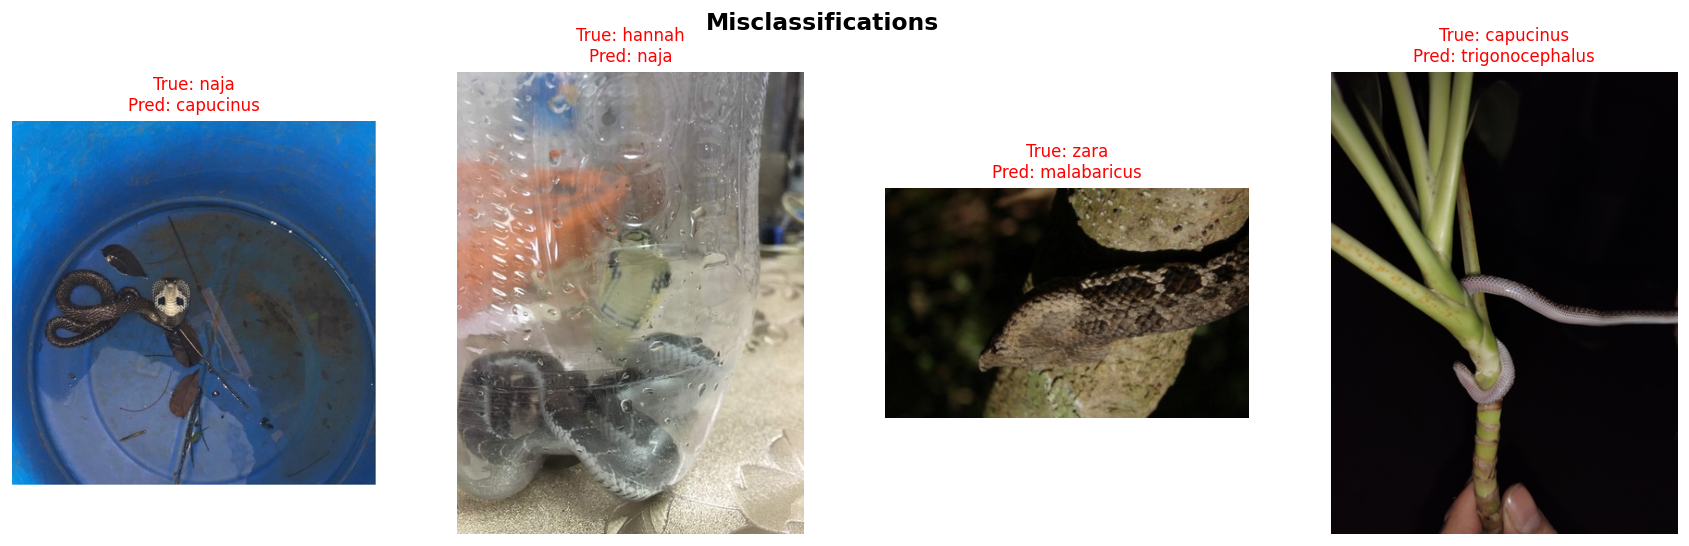

In [26]:
def plot_samples(indices, title):
    n = min(len(indices), 4)
    if n == 0: return
    fig, axes = plt.subplots(1, n, figsize=(18, 5))
    if n == 1: axes = [axes]
    for i in range(n):
        idx = indices[i]
        path = image_paths[idx_test[idx]]
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        axes[i].imshow(img)
        true_lab = label_names[int(y_test[idx])].split('_')[-1]
        pred_lab = label_names[int(y_pred[idx])].split('_')[-1]
        conf = confidences[idx] if BEST == 'logreg' else "N/A"

        color = 'green' if y_test[idx] == y_pred[idx] else 'red'
        axes[i].set_title(f"True: {true_lab}\nPred: {pred_lab}\nConf: {conf:.2f}" if isinstance(conf, float) else f"True: {true_lab}\nPred: {pred_lab}", color=color, fontsize=10)
        axes[i].axis('off')
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.show()

mis_indices = np.where(y_test != y_pred)[0]
cor_indices = np.where(y_test == y_pred)[0]

random.seed(RANDOM_SEED)
if len(cor_indices) > 0:
    plot_samples(random.sample(list(cor_indices), min(len(cor_indices), 4)), "Correct Predictions")
if len(mis_indices) > 0:
    plot_samples(random.sample(list(mis_indices), min(len(mis_indices), 4)), "Misclassifications")